In [2]:
import tensorflow as tf
assert tf.__version__.startswith('2')
from tensorflow.keras import backend as K
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.optimizers import Nadam

import glob
import random
import pretty_midi
import IPython

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import pickle

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dropout, Dense, LeakyReLU

# Get the midi file

In [4]:
def get_list_midi(folder = 'pool/*.mid'):
    list_all_midi = glob.glob(folder)
    random.shuffle(list_all_midi)
    return list_all_midi

list_all_midi = get_list_midi()

# Define the tokenizer

In [5]:
class NoteTokenizer:
    #初始化映射字典、音符計數和頻率計數
    def __init__(self):
        self.notes_to_index = {}
        self.index_to_notes = {}
        self.num_of_word = 0
        self.unique_word = 0
        self.notes_freq = {}
    
    #將一組音符（字符串）轉換為對應的索引
    def transform(self,list_array):
        transformed_list = []
        for instance in list_array:
            transformed_list.append([self.notes_to_index[note] for note in instance])
        return np.array(transformed_list, dtype=np.int32)
    
    #逐步添加音符到字典中
    def partial_fit(self, notes):
        for note in notes:
            note_str = ','.join(str(a) for a in note)
            if note_str in self.notes_freq:
                self.notes_freq[note_str] += 1
                self.num_of_word += 1
            else:
                self.notes_freq[note_str] = 1
                self.unique_word += 1
                self.num_of_word += 1
                self.notes_to_index[note_str], self.index_to_notes[self.unique_word] = self.unique_word, note_str

    #主動添加新音符（如空音符'e'）        
    def add_new_note(self, note):
        assert note not in self.notes_to_index
        self.unique_word += 1
        self.notes_to_index[note], self.index_to_notes[self.unique_word] = self.unique_word, note

#生成送入神經網絡的音符序列，返回輸入和目標序列       
def generate_batch_song(list_all_midi, batch_music=16, start_index=0, fs=30, seq_len=5):
    assert len(list_all_midi) >= batch_music
    dict_time_notes = generate_dict_time_notes(list_all_midi, batch_music, start_index, fs)
    
    list_musics = process_notes_in_song(dict_time_notes, seq_len)
    collected_list_input, collected_list_target = [], []
     
    for music in list_musics:
        list_training, list_target = generate_input_and_target(music, seq_len)
        collected_list_input += list_training
        collected_list_target += list_target
    return collected_list_input, collected_list_target

#將MIDI文件轉換成時間與音符矩陣的字典
def generate_dict_time_notes(list_all_midi, batch_song = 16, start_index=0, fs=30):
    assert len(list_all_midi) >= batch_song
    dict_time_notes = {}
    process_midi = range(start_index,  min(start_index + batch_song, len(list_all_midi)))
    for i in process_midi:
        midi_file_name = list_all_midi[i]
        try:
            midi_pretty_format = pretty_midi.PrettyMIDI(midi_file_name)
            piano_midi = midi_pretty_format.instruments[0]
            piano_roll = piano_midi.get_piano_roll(fs=fs)
            dict_time_notes[i] = piano_roll
        except Exception as e:
            print(e)
            print("broken file : {}".format(midi_file_name))
            pass
    return dict_time_notes

#生成適合模型的輸入（Inputs）和輸出（Target）
def generate_input_and_target(dict_keys_time, seq_len=5):
    start_time, end_time = list(dict_keys_time.keys())[0], list(dict_keys_time.keys())[-1]
    list_training, list_target = [], []
    for index_enum, time in enumerate(range(start_time, end_time)):
        list_append_training, list_append_target = [], []
        start_iterate = 0

        if index_enum < seq_len:
            start_iterate = seq_len - index_enum - 1
            for i in range(start_iterate):
                list_append_training.append('e')


        for i in range(start_iterate,seq_len):
            index_enum = time - (seq_len - i - 1)
            if index_enum in dict_keys_time:
                list_append_training.append(','.join(str(x) for x in dict_keys_time[index_enum]))      
            else:
                list_append_training.append('e')

        if time+1 in dict_keys_time:
            list_append_target.append(','.join(str(x) for x in dict_keys_time[time+1]))
        else:
            list_append_target.append('e')
        list_training.append(list_append_training)
        list_target.append(list_append_target)
    return list_training, list_target

def process_notes_in_song(dict_time_notes, seq_len = 5):

    list_of_dict_keys_time = []
    
    for key in dict_time_notes:
        sample = dict_time_notes[key]
        times = np.unique(np.where(sample > 0)[1])
        index = np.where(sample > 0)
        dict_keys_time = {}

        for time in times:
            index_where = np.where(index[1] == time)
            notes = index[0][index_where]
            dict_keys_time[time] = notes
        list_of_dict_keys_time.append(dict_keys_time)
    return list_of_dict_keys_time

# Process the mid file

In [6]:
note_tokenizer = NoteTokenizer()
#處理每個MIDI文件
for i in range(len(list_all_midi)):
    dict_time_notes = generate_dict_time_notes(list_all_midi, batch_song=1, start_index=i, fs=5)
    full_notes = process_notes_in_song(dict_time_notes)
    for note in full_notes:
        note_tokenizer.partial_fit(list(note.values()))


example of data process
notes = [
    (60, 120, 240),
    (62, 240, 240),
    (64, 180, 240),
    (65, 240, 240),
    (67, 300, 240),
    (69, 180, 240),
    (71, 240, 240),
    (72, 240, 240)
]

dict_time_notes = {
    0: {
        0: [60],      # At time 0, note 60 starts
        120: [62],    # At time 120, note 62 starts
        180: [64, 69], # At time 180, notes 64 and 69 start
        240: [65, 71, 72], # At time 240, notes 65, 71 and 72 start
        300: [67]     # At time 300, note 67 starts
    }
}

list_training = [
    ['e', 'e', 'e', 'e', '60'],
    ['e', 'e', 'e', '60', '62'],
    ['e', 'e', '60', '62', '64,69'],
    ['e', '60', '62', '64,69', '65,71,72'],
    ['60', '62', '64,69', '65,71,72', '67']
]

list_target = [
    ['62'],
    ['64,69'],
    ['65,71,72'],
    ['67'],
    ['e']
]

transformed_list = np.array([
    [6, 6, 6, 6, 1],
    [6, 6, 6, 1, 2],
    [6, 6, 1, 2, 3],
    [6, 1, 2, 3, 4],
    [1, 2, 3, 4, 5]
], dtype=np.int32)



# Add the space

In [7]:
note_tokenizer.add_new_note('e')
unique_notes = note_tokenizer.unique_word

In [8]:
def music_model(seq_len, unique_notes, dropout=0.3, output_emb=100, rnn_unit=128, dense_unit=64):
    model = Sequential()
    model.add(Embedding(input_dim=unique_notes + 1, output_dim=output_emb, input_length=seq_len))
    model.add(Bidirectional(GRU(rnn_unit, return_sequences=True)))
    model.add(Dropout(dropout))
    model.add(Bidirectional(GRU(rnn_unit, return_sequences=True)))
    model.add(Dropout(dropout))
    model.add(Bidirectional(GRU(rnn_unit)))
    model.add(Dropout(dropout))
    model.add(Dense(dense_unit))
    model.add(LeakyReLU())
    model.add(Dense(unique_notes + 1, activation="softmax"))
    return model

seq_len = 5
model = music_model(seq_len, unique_notes)

optimizer = Nadam()
loss_fn = sparse_categorical_crossentropy

c:\DL\venv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
model.compile(optimizer=optimizer, loss=loss_fn)

In [10]:
class TrainModel:
  
    def __init__(self, epochs, note_tokenizer, list_all_midi, frame_per_second, 
               batch_nnet_size, batch_song, optimizer, loss_fn, total_songs, model):
        self.epochs = epochs
        self.note_tokenizer = note_tokenizer
        self.list_all_midi = list_all_midi
        self.frame_per_second = frame_per_second
        self.batch_nnet_size = batch_nnet_size
        self.batch_song = batch_song
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.total_songs = total_songs
        self.model = model
    
    def train(self):     
        loss_list = []
        steps_nnet = 0
        loss_total = 0
        for epoch in range(self.epochs):
            # for each epochs, we shufle the list of all the datasets
            random.shuffle(self.list_all_midi)
            steps = 0
            # We will iterate all songs by self.song_size
            for i in range(0,self.total_songs, self.batch_song):

                steps += 1
                inputs_nnet_large, outputs_nnet_large = generate_batch_song(
                    self.list_all_midi, self.batch_song, start_index=i, fs=self.frame_per_second, 
                    seq_len=seq_len) # We use the function that have been defined here
                inputs_nnet_large = np.array(self.note_tokenizer.transform(inputs_nnet_large), dtype=np.int32)
                outputs_nnet_large = np.array(self.note_tokenizer.transform(outputs_nnet_large), dtype=np.int32)

                index_shuffled = np.arange(start=0, stop=len(inputs_nnet_large))
                np.random.shuffle(index_shuffled)
                
                
                for nnet_steps in range(0,len(index_shuffled),self.batch_nnet_size):
                    steps_nnet += 1
                    current_index = index_shuffled[nnet_steps:nnet_steps+self.batch_nnet_size]
                    inputs_nnet, outputs_nnet = inputs_nnet_large[current_index], outputs_nnet_large[current_index]

                    # To make sure no exception thrown by tensorflow on autograph
                    if len(inputs_nnet) // self.batch_nnet_size != 1:
                        break
                    loss = self.train_step(inputs_nnet, outputs_nnet)
                    loss_list.append(tf.math.reduce_sum(loss))
                    if steps_nnet % 20 == 0:
                        print("epochs {} | Steps {} | loss : {}".format(epoch + 1, steps_nnet, tf.math.reduce_sum(loss)))
        return loss_list
            
    @tf.function
    def train_step(self, inputs, targets):
        with tf.GradientTape() as tape:
            prediction = self.model(inputs)
            loss = self.loss_fn(targets, prediction)
        gradients = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))
        return loss

# Train

In [21]:
seq_len = 5
EPOCHS = 20
BATCH_SONG = 1
BATCH_NNET_SIZE = 64
TOTAL_SONGS = len(list_all_midi)
FRAME_PER_SECOND = 5

train_class = TrainModel(EPOCHS, note_tokenizer, list_all_midi, FRAME_PER_SECOND,
                  BATCH_NNET_SIZE, BATCH_SONG, optimizer, loss_fn, TOTAL_SONGS, model)

losses = train_class.train()

# Plot the loss function

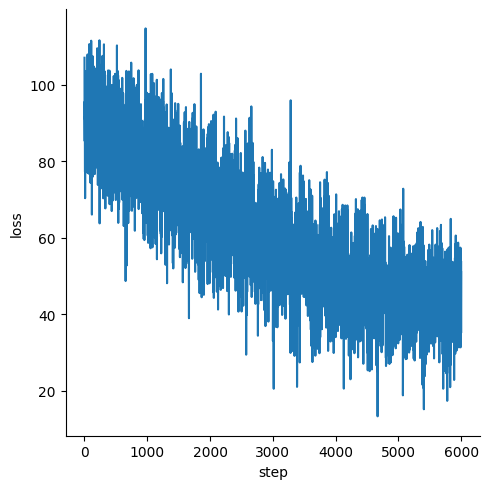

In [22]:
losses = [loss.numpy() for loss in losses]
df = pd.DataFrame(dict(step=np.arange(len(losses)),loss=losses))
sns.relplot(x='step',y='loss',kind='line',data=df)

# save the model and the tokenizer

In [23]:
model.save('model.h5')
pickle.dump( note_tokenizer, open( "tokenizer.p", "wb" ) )

# Load the model and the tokenizer

In [24]:
model = tf.keras.models.load_model('model.h5')
note_tokenizer  = pickle.load(open("tokenizer.p", "rb" ))

# Generate mid

In [25]:
def piano_roll_to_pretty_midi(piano_roll, fs=100, program=0):
    notes, frames = piano_roll.shape
    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=program)

    # pad 1 column of zeros so we can acknowledge inital and ending events
    piano_roll = np.pad(piano_roll, [(0, 0), (1, 1)], 'constant')

    # use changes in velocities to find note on / note off events
    velocity_changes = np.nonzero(np.diff(piano_roll).T)

    # keep track on velocities and note on times
    prev_velocities = np.zeros(notes, dtype=int)
    note_on_time = np.zeros(notes)

    for time, note in zip(*velocity_changes):
        # use time + 1 because of padding above
        velocity = piano_roll[note, time + 1]
        time = time / fs
        if velocity > 0:
            if prev_velocities[note] == 0:
                note_on_time[note] = time
                prev_velocities[note] = velocity
        else:
            pm_note = pretty_midi.Note(
                velocity=prev_velocities[note],
                pitch=note,
                start=note_on_time[note],
                end=time)
            instrument.notes.append(pm_note)
            prev_velocities[note] = 0
    pm.instruments.append(instrument)
    return pm

def generate_from_random(unique_notes, seq_len=50):
    generate = np.random.randint(0,unique_notes,seq_len).tolist()
    return generate
    
def generate_from_one_note(note_tokenizer, new_notes='35'):
    generate = [note_tokenizer.notes_to_index['e'] for i in range(49)]
    generate += [note_tokenizer.notes_to_index[new_notes]]
    return generate

def generate_notes(generate, model, unique_notes, max_generated=1000, seq_len=50):
    for i in range(max_generated):
        test_input = np.array([generate])[:,i:i+seq_len]
        predicted_note = model.predict(test_input)
        random_note_pred = np.random.choice(unique_notes+1, 1, replace=False, p=predicted_note[0])
        generate.append(random_note_pred[0])
    return generate

def write_midi_file_from_generated(generate, midi_file_name = "result.mid", start_index=49, fs=8, max_generated=1000):
    note_string = [note_tokenizer.index_to_notes[ind_note] for ind_note in generate]
    array_piano_roll = np.zeros((128,max_generated+1), dtype=np.int16)
    for index, note in enumerate(note_string[start_index:]):
        if note == 'e':
            pass
        else:
            splitted_note = note.split(',')
            for j in splitted_note:
                array_piano_roll[int(j),index] = 1
    generate_to_midi = piano_roll_to_pretty_midi(array_piano_roll, fs=fs)
    print("Tempo {}".format(generate_to_midi.estimate_tempo()))
    for note in generate_to_midi.instruments[0].notes:
        note.velocity = 100
    generate_to_midi.write(midi_file_name)

# Generate with random

In [30]:
max_generate = 200
unique_notes = note_tokenizer.unique_word
seq_len=5
generate = generate_from_random(unique_notes, seq_len)
generate = generate_notes(generate, model, unique_notes, max_generate, seq_len)
write_midi_file_from_generated(generate, "example1.mid", start_index=seq_len-1, fs=7, max_generated = max_generate)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━

# Generate with first note set

In [36]:
max_generate = 300
unique_notes = note_tokenizer.unique_word
seq_len=5
generate = generate_from_one_note(note_tokenizer, '60')
generate = generate_notes(generate, model, unique_notes, max_generate, seq_len)
write_midi_file_from_generated(generate, "example2.mid", start_index=seq_len+60, fs=5, max_generated = max_generate)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━